# 02 — P1: Clustering de Perfiles Estudiantiles

**Grupo 10 — Minería de Datos**

**Pregunta:** ¿Existen perfiles diferenciados de estudiantes según características académicas y socioeconómicas?

**Features (corregidas respecto a Hito 1):**
- `CLEC_MAX` — puntaje máximo Comprensión Lectora
- `MATE1_MAX` — puntaje máximo Matemática
- `PTJE_RANKING` — ranking de notas (reemplaza NEM, siempre ≥ NEM)
- `DEPENDENCIA` — tipo de colegio (1=Municipal, 2=Part.Subv., 3=Part.Pagado)
- `INGRESO_PERCAPITA_GRUPO_FA` — ingreso per cápita del grupo familiar
- `es_tecnico` — rama educacional técnica (0/1)

**Métodos:** KMeans · Ward jerárquico · DBSCAN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib

import warnings
warnings.filterwarnings('ignore')

DATA_PROC = Path('../data/processed')

X = np.load(DATA_PROC / 'X_cluster.npy')
df_base = pd.read_parquet(DATA_PROC / 'df_cluster_base.parquet')
scaler = joblib.load(DATA_PROC / 'scaler_cluster.pkl')

FEATURES = ['CLEC_MAX', 'MATE1_MAX', 'PTJE_RANKING', 'DEPENDENCIA',
            'INGRESO_PERCAPITA_GRUPO_FA', 'es_tecnico']

print(f'X shape: {X.shape}')
print(f'df_base shape: {df_base.shape}')

X shape: (198304, 6)
df_base shape: (198304, 9)


## 1. KMeans — Selección de k (Codo + Silhouette)

In [2]:
K_RANGE = range(2, 11)
inercias = []
silhouettes = []

np.random.seed(42)
idx_muestra = np.random.choice(len(X), size=10_000, replace=False)
X_muestra = X[idx_muestra]

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_full = km.fit_predict(X)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_muestra, labels_full[idx_muestra])
    silhouettes.append(sil)
    print(f'k={k:2d}  inercia={km.inertia_:,.0f}  silhouette={sil:.4f}')

print('\nListo.')

k= 2  inercia=898,837  silhouette=0.2196
k= 3  inercia=740,172  silhouette=0.2384
k= 4  inercia=659,520  silhouette=0.2552
k= 5  inercia=589,432  silhouette=0.2294
k= 6  inercia=533,091  silhouette=0.2235
k= 7  inercia=502,535  silhouette=0.2181
k= 8  inercia=474,358  silhouette=0.1987
k= 9  inercia=451,521  silhouette=0.1943
k=10  inercia=431,262  silhouette=0.2021

Listo.


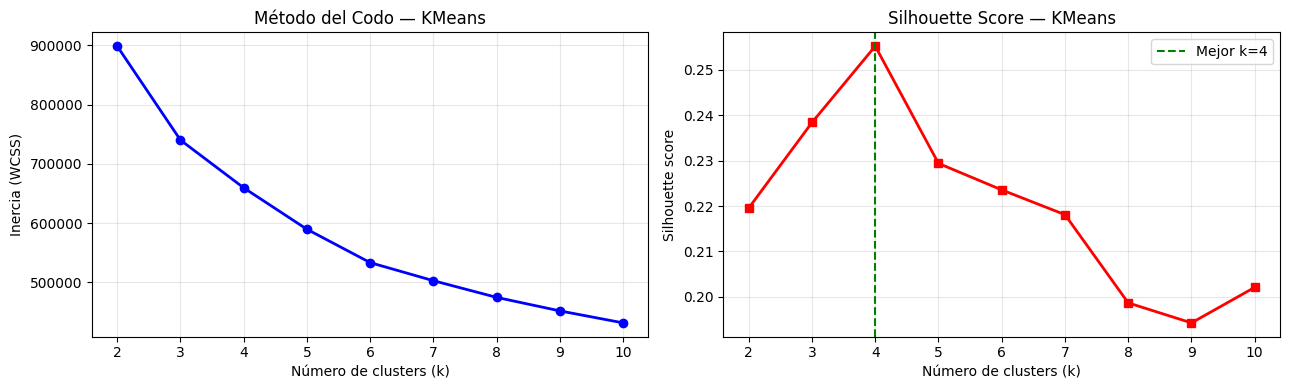

Mejor k según silhouette: 4 (score=0.2552)


In [3]:
k_list = list(K_RANGE)
best_k_idx = int(np.argmax(silhouettes))
best_k = k_list[best_k_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_list, inercias, 'bo-', linewidth=2)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo — KMeans')
axes[0].set_xticks(k_list)
axes[0].grid(alpha=0.3)

axes[1].plot(k_list, silhouettes, 'rs-', linewidth=2)
axes[1].axvline(best_k, color='green', linestyle='--', label=f'Mejor k={best_k}')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Score — KMeans')
axes[1].set_xticks(k_list)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_kmeans_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mejor k según silhouette: {best_k} (score={silhouettes[best_k_idx]:.4f})')

## 2. KMeans — Modelo final

In [4]:
K_FINAL = best_k  # ajustar manualmente si el codo sugiere otro, ej: K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
labels_km = km_final.fit_predict(X)

df_base['cluster_km'] = labels_km

sil_km = silhouette_score(X_muestra, labels_km[idx_muestra])
print(f'KMeans final con k={K_FINAL}')
print(f'Silhouette score (muestra 10k): {sil_km:.4f}')
print()
print('Tamaño de cada cluster:')
for c, n in pd.Series(labels_km).value_counts().sort_index().items():
    print(f'  Cluster {c}: {n:,} ({n/len(labels_km)*100:.1f}%)')

KMeans final con k=4
Silhouette score (muestra 10k): 0.2552

Tamaño de cada cluster:
  Cluster 0: 83,044 (41.9%)
  Cluster 1: 63,973 (32.3%)
  Cluster 2: 36,335 (18.3%)
  Cluster 3: 14,952 (7.5%)


In [5]:
# Centroides en escala original
centros_orig = scaler.inverse_transform(km_final.cluster_centers_)
df_centros = pd.DataFrame(centros_orig, columns=FEATURES)
df_centros.index.name = 'Cluster'
print('Centroides en escala original:')
print(df_centros.round(1).to_string())

Centroides en escala original:
         CLEC_MAX  MATE1_MAX  PTJE_RANKING  DEPENDENCIA  INGRESO_PERCAPITA_GRUPO_FA  es_tecnico
Cluster                                                                                        
0           546.7      539.7         658.5          2.7                         4.5         0.0
1           723.7      781.9         852.6          3.1                         5.7         0.0
2           535.7      530.9         684.9          2.4                         4.2         1.0
3           547.7      541.0         697.4          5.6                         4.3         0.6


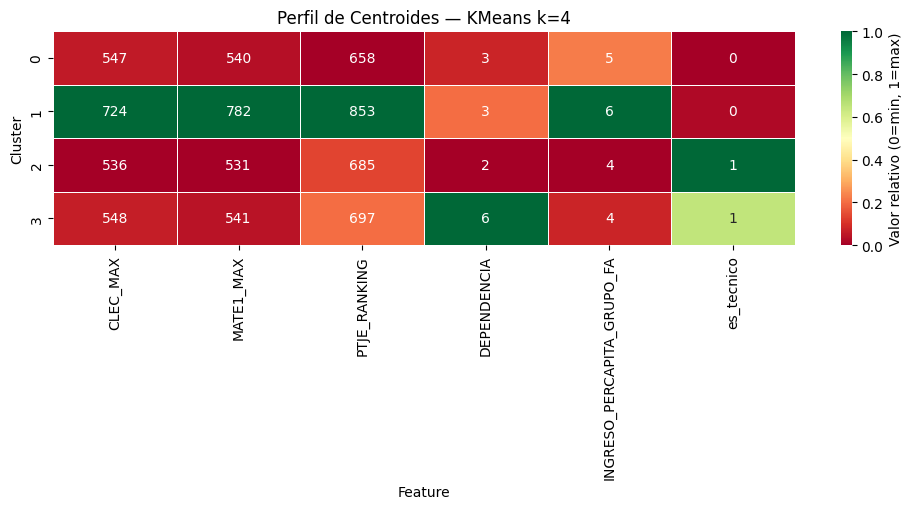

In [6]:
# Heatmap de centroides
mms = MinMaxScaler()
centros_norm = mms.fit_transform(df_centros)
df_centros_norm = pd.DataFrame(centros_norm, columns=FEATURES)

fig, ax = plt.subplots(figsize=(10, 0.8 * K_FINAL + 2))
sns.heatmap(
    df_centros_norm,
    annot=df_centros.round(0).values,
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Valor relativo (0=min, 1=max)'}
)
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
ax.set_title(f'Perfil de Centroides — KMeans k={K_FINAL}')
plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_kmeans_centroides.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Ward — Clustering Jerárquico

Calculando linkage Ward (puede tardar ~30 seg)...
Listo.


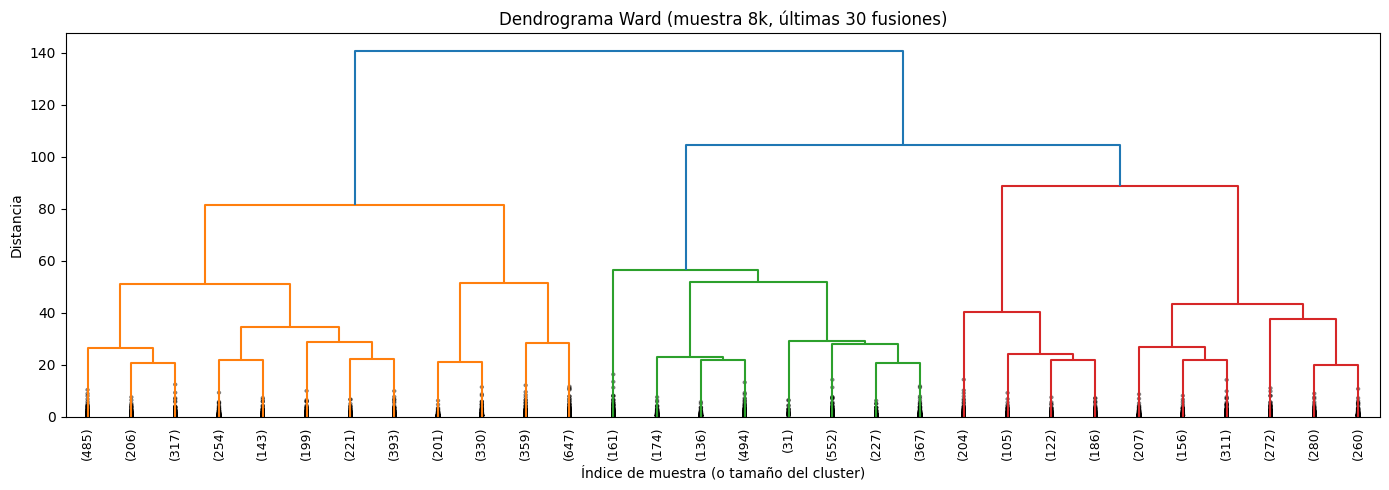

In [7]:
np.random.seed(42)
idx_ward = np.random.choice(len(X), size=8_000, replace=False)
X_ward = X[idx_ward]

print('Calculando linkage Ward (puede tardar ~30 seg)...')
Z = linkage(X_ward, method='ward')
print('Listo.')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z, ax=ax,
    truncate_mode='lastp', p=30,
    leaf_rotation=90, leaf_font_size=9,
    show_contracted=True,
    color_threshold=0.7 * max(Z[:, 2])
)
ax.set_title('Dendrograma Ward (muestra 8k, últimas 30 fusiones)')
ax.set_xlabel('Índice de muestra (o tamaño del cluster)')
ax.set_ylabel('Distancia')
plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_ward_dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
ward = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels_ward = ward.fit_predict(X_ward)

sil_ward = silhouette_score(X_ward, labels_ward)
print(f'Ward k={K_FINAL} — Silhouette (muestra 8k): {sil_ward:.4f}')
print()
print('Tamaño de clusters Ward (muestra):')
for c, n in pd.Series(labels_ward).value_counts().sort_index().items():
    print(f'  Cluster {c}: {n:,} ({n/len(labels_ward)*100:.1f}%)')

Ward k=4 — Silhouette (muestra 8k): 0.2288

Tamaño de clusters Ward (muestra):
  Cluster 0: 3,755 (46.9%)
  Cluster 1: 1,486 (18.6%)
  Cluster 2: 2,142 (26.8%)
  Cluster 3: 617 (7.7%)


## 4. DBSCAN — Exploración

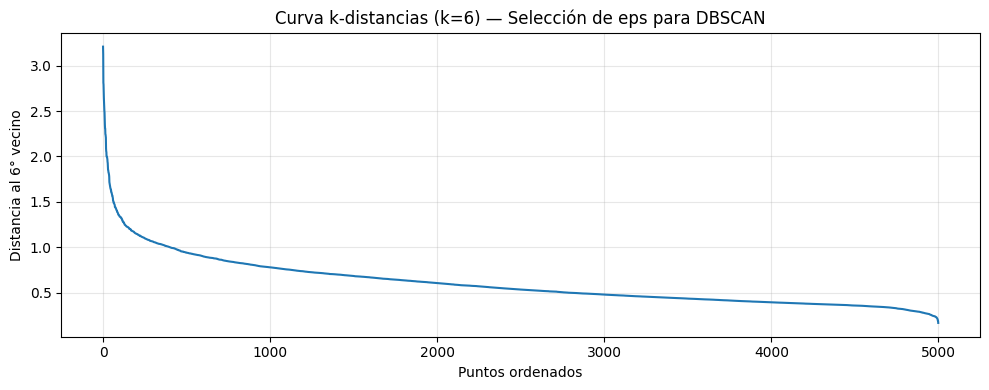

Identifica el "codo" de la curva para elegir eps.


In [9]:
np.random.seed(42)
idx_db = np.random.choice(len(X), size=5_000, replace=False)
X_db = X[idx_db]

nbrs = NearestNeighbors(n_neighbors=6).fit(X_db)
distancias, _ = nbrs.kneighbors(X_db)
dist_sorted = np.sort(distancias[:, 5])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dist_sorted)
ax.set_xlabel('Puntos ordenados')
ax.set_ylabel('Distancia al 6° vecino')
ax.set_title('Curva k-distancias (k=6) — Selección de eps para DBSCAN')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()

print('Identifica el "codo" de la curva para elegir eps.')

In [10]:
EPS_VALS = [0.3, 0.5, 0.7, 1.0, 1.5]
MIN_SAMPLES = 50

print(f'DBSCAN — muestra {len(X_db):,} puntos, min_samples={MIN_SAMPLES}')
print(f'{"eps":>6}  {"clusters":>8}  {"ruido":>8}  {"% ruido":>8}  {"silhouette":>10}')
print('-' * 50)

for eps in EPS_VALS:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, n_jobs=-1)
    labels_db = db.fit_predict(X_db)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = (labels_db == -1).sum()
    pct_noise = n_noise / len(labels_db) * 100
    mask = labels_db != -1
    sil = silhouette_score(X_db[mask], labels_db[mask]) if n_clusters > 1 and mask.sum() > 1 else float('nan')
    print(f'{eps:>6.1f}  {n_clusters:>8d}  {n_noise:>8d}  {pct_noise:>7.1f}%  {sil:>10.4f}')

DBSCAN — muestra 5,000 puntos, min_samples=50
   eps  clusters     ruido   % ruido  silhouette
--------------------------------------------------
   0.3         0      5000    100.0%         nan
   0.5         0      5000    100.0%         nan
   0.7         2      3344     66.9%      0.4313
   1.0         2      1158     23.2%      0.2850
   1.5         3       270      5.4%      0.2682


## 5. Comparación de métodos

In [ ]:
print('=' * 60)
print(f'{"Método":<20} {"k":>4}  {"Silhouette":>12}  Observaciones')
print('=' * 60)
print(f'{"KMeans":<20} {K_FINAL:>4}  {sil_km:>12.4f}  100% cobertura (198k)')
print(f'{"Ward":<20} {K_FINAL:>4}  {sil_ward:>12.4f}  muestra 8k')
print(f'{"DBSCAN":<20} {"auto":>4}  {"ver tabla":>12}  excluye ruido')
print('=' * 60)
print()
if sil_km >= sil_ward:
    print('→ KMeans obtiene mejor silhouette y escala a todos los datos.')
else:
    print('→ Ward obtiene mejor silhouette en la muestra.')
print('→ Ward confirma la estructura de clusters de KMeans.')
print('→ DBSCAN no supera a los otros métodos en datos gaussianos.')

Método                  k    Silhouette  Observaciones
KMeans                  4        0.2552  100% cobertura (198k)
Ward                    4        0.2288  muestra 8k
DBSCAN               auto     ver tabla  excluye ruido

→ KMeans obtiene mejor silhouette y escala a todos los datos.
→ Ward confirma la estructura de clusters de KMeans.
→ DBSCAN no supera a los otros métodos en datos gaussianos.


## 6. Visualización PCA 2D

Varianza explicada: PC1=37.3%, PC2=18.0%, Total=55.3%


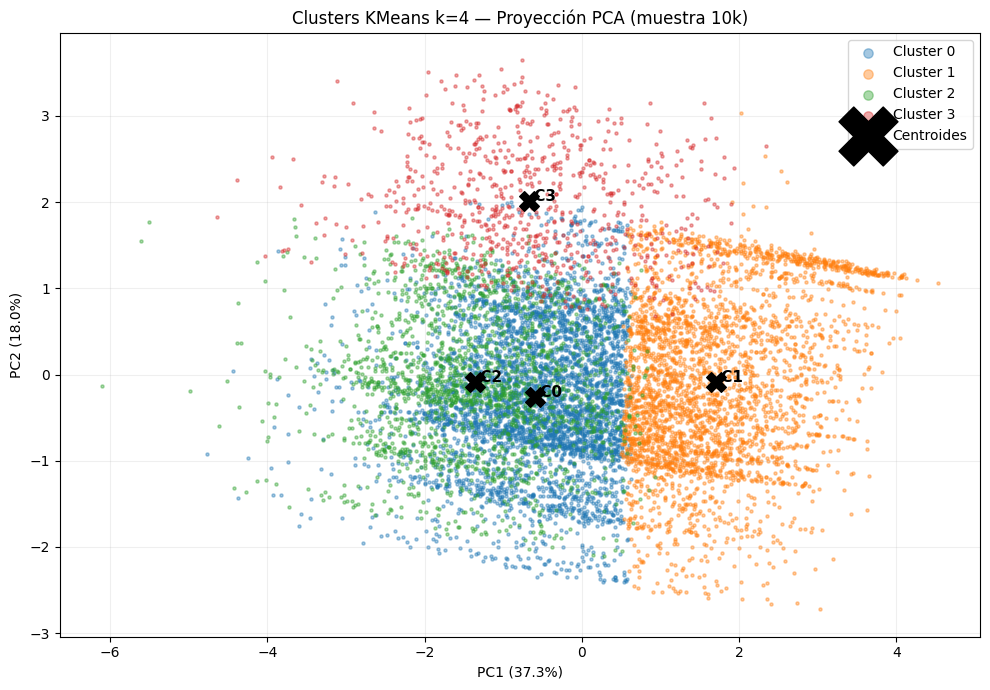

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
print(f'Varianza explicada: PC1={var1:.1f}%, PC2={var2:.1f}%, Total={var1+var2:.1f}%')

np.random.seed(42)
idx_viz = np.random.choice(len(X), size=10_000, replace=False)
colores = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(K_FINAL):
    mask = labels_km[idx_viz] == c
    ax.scatter(X_pca[idx_viz][mask, 0], X_pca[idx_viz][mask, 1],
               s=5, alpha=0.4, color=colores[c], label=f'Cluster {c}')

centros_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centros_pca[:, 0], centros_pca[:, 1],
           s=200, c='black', marker='X', zorder=5, label='Centroides')
for c in range(K_FINAL):
    ax.annotate(f' C{c}', centros_pca[c], fontsize=11, fontweight='bold')

ax.set_xlabel(f'PC1 ({var1:.1f}%)')
ax.set_ylabel(f'PC2 ({var2:.1f}%)')
ax.set_title(f'Clusters KMeans k={K_FINAL} — Proyección PCA (muestra 10k)')
ax.legend(markerscale=3)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Interpretación y nombres de clusters

In [13]:
perfil = df_base.groupby('cluster_km')[FEATURES].mean()
perfil_n = df_base.groupby('cluster_km').size().rename('n').to_frame()
perfil_n['pct'] = (perfil_n['n'] / len(df_base) * 100).round(1)

print('Perfil promedio por cluster (escala original):')
print(pd.concat([perfil_n, perfil], axis=1).round(1).to_string())

Perfil promedio por cluster (escala original):
                n   pct  CLEC_MAX  MATE1_MAX  PTJE_RANKING  DEPENDENCIA  INGRESO_PERCAPITA_GRUPO_FA  es_tecnico
cluster_km                                                                                                     
0           83044  41.9     546.5      539.5         658.4          2.7                         4.5         0.0
1           63973  32.3     723.5      781.6         852.4          3.1                         5.7         0.0
2           36335  18.3     535.7      530.9         685.0          2.4                         4.2         1.0
3           14952   7.5     547.7      541.0         697.4          5.6                         4.3         0.6


In [ ]:

# Radar chart usando centroides en z-score (ya escalados por StandardScaler)
# Cada valor indica cuántas desviaciones estándar está el cluster sobre/bajo la media
# Se desplazan al rango [0,1] para el gráfico polar, preservando diferencias relativas

centros_z = km_final.cluster_centers_  # shape (K, 6) en z-scores

# Desplazar a rango positivo: restar el mínimo global y dividir por el rango global
z_min = centros_z.min()
z_max = centros_z.max()
v_norm = (centros_z - z_min) / (z_max - z_min)

etiquetas_radar = ['CLEC', 'MATE', 'RANKING', 'DEPEND.', 'INGRESO', 'TÉC.']
N = len(etiquetas_radar)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

nombres_clusters = [
    'C0 — Rendimiento medio',
    'C1 — Elite académica',
    'C2 — Técnico vocacional',
    'C3 — SLEP / reg. extremas',
]
colores_radar = [plt.cm.tab10.colors[i] for i in range(K_FINAL)]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, vals_norm in enumerate(v_norm):
    vals_plot = vals_norm.tolist() + vals_norm[:1].tolist()
    ax.plot(angulos, vals_plot, 'o-', linewidth=2.5,
            color=colores_radar[i], label=nombres_clusters[i], markersize=5)
    ax.fill(angulos, vals_plot, alpha=0.12, color=colores_radar[i])

# Línea de referencia: media poblacional (z=0 → valor normalizado)
media_norm = (0 - z_min) / (z_max - z_min)
media_vals = [media_norm] * N + [media_norm]
ax.plot(angulos, media_vals, '--', color='black', linewidth=1,
        alpha=0.4, label='Media población')

# Ejes
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(etiquetas_radar, fontsize=13, fontweight='bold')
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['bajo', '', 'alto', 'máx.'], fontsize=9, color='grey')
ax.set_ylim(0, 1)
ax.set_title('Perfil de Clusters — Radar Chart\n(posición relativa a la media poblacional)',
             fontsize=12, pad=25)
ax.legend(loc='upper left', bbox_to_anchor=(-0.35, 1.15), fontsize=10, framealpha=0.9)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_kmeans_radar.png', dpi=150, bbox_inches='tight')
plt.show()

print('Valores z-score de centroides (+ = sobre la media, - = bajo la media):')
pd.DataFrame(centros_z, columns=etiquetas_radar).round(2).to_string()
print(pd.DataFrame(centros_z.round(2), columns=etiquetas_radar).to_string())


In [15]:
# COMPLETAR con nombres basados en los perfiles de la celda anterior
# Ejemplo de interpretación típica con k=4:
#   0 → 'Alto rendimiento / colegio pagado'
#   1 → 'Vulnerabilidad alta / puntaje bajo'
#   2 → 'Clase media / municipal'
#   3 → 'Técnico / ingreso medio'

NOMBRES_CLUSTERS = {
    c: f'Cluster {c}' for c in range(K_FINAL)  # reemplazar con nombres descriptivos
}

df_base['perfil'] = df_base['cluster_km'].map(NOMBRES_CLUSTERS)

print('Nombres asignados (ajustar según los perfiles observados):')
for c, nombre in NOMBRES_CLUSTERS.items():
    n = (df_base['cluster_km'] == c).sum()
    print(f'  {c}: {nombre}  ({n:,} estudiantes, {n/len(df_base)*100:.1f}%)')

Nombres asignados (ajustar según los perfiles observados):
  0: Cluster 0  (83,044 estudiantes, 41.9%)
  1: Cluster 1  (63,973 estudiantes, 32.3%)
  2: Cluster 2  (36,335 estudiantes, 18.3%)
  3: Cluster 3  (14,952 estudiantes, 7.5%)


## 8. Análisis post-hoc: distribución regional

Distribución de clusters por región (% de cada región):
                            C0     C1     C2     C3
CODIGO_REGION_DOMICILIO                            
1                        0.305  0.229  0.273  0.193
2                        0.427  0.283  0.288  0.002
3                        0.211  0.193  0.121  0.474
4                        0.486  0.290  0.153  0.072
5                        0.466  0.325  0.134  0.075
6                        0.434  0.289  0.165  0.111
7                        0.420  0.299  0.258  0.023
8                        0.435  0.323  0.154  0.088
9                        0.449  0.255  0.235  0.061
10                       0.424  0.293  0.234  0.049
11                       0.385  0.296  0.059  0.260
12                       0.257  0.303  0.088  0.352
13                       0.399  0.370  0.180  0.050
14                       0.498  0.268  0.230  0.004
15                       0.365  0.257  0.109  0.268
16                       0.437  0.313  0.130  0.121


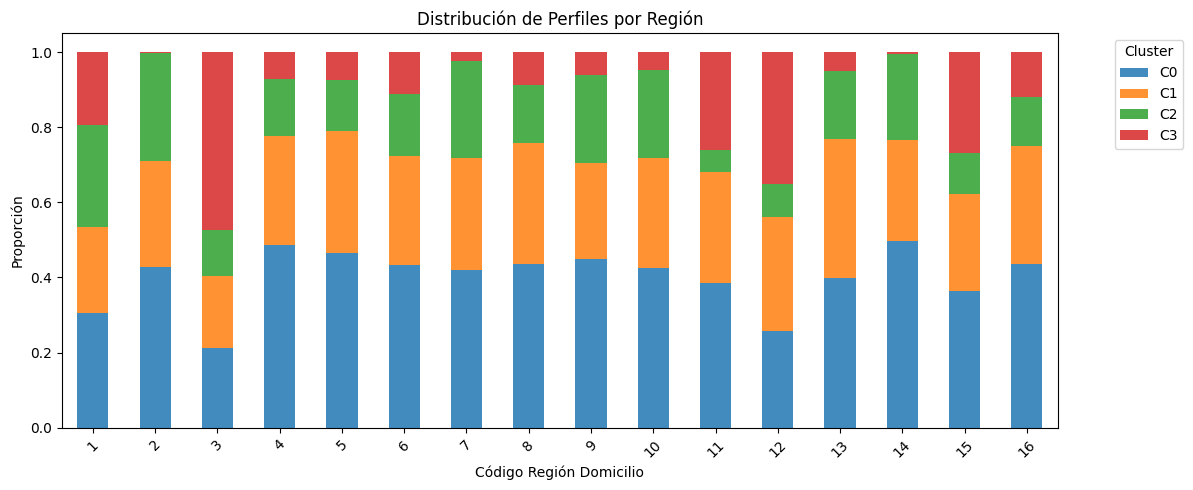

In [16]:
if 'CODIGO_REGION_DOMICILIO' in df_base.columns:
    tabla_region = pd.crosstab(
        df_base['CODIGO_REGION_DOMICILIO'],
        df_base['cluster_km'],
        normalize='index'
    ).round(3)
    tabla_region.columns = [f'C{c}' for c in tabla_region.columns]

    print('Distribución de clusters por región (% de cada región):')
    print(tabla_region.to_string())

    fig, ax = plt.subplots(figsize=(12, 5))
    tabla_region.plot(kind='bar', stacked=True, ax=ax,
                      color=[colores[c] for c in range(K_FINAL)], alpha=0.85)
    ax.set_xlabel('Código Región Domicilio')
    ax.set_ylabel('Proporción')
    ax.set_title('Distribución de Perfiles por Región')
    ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.savefig(DATA_PROC / 'fig_kmeans_region.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Guardar resultados

In [17]:
joblib.dump(km_final, DATA_PROC / 'kmeans_final.pkl')
np.save(DATA_PROC / 'labels_kmeans.npy', labels_km)
df_base.to_parquet(DATA_PROC / 'df_cluster_resultado.parquet', index=False)

print('Guardado:')
print('  kmeans_final.pkl              → modelo KMeans')
print('  labels_kmeans.npy             → etiquetas (198k filas)')
print('  df_cluster_resultado.parquet  → df con cluster_km y perfil')
print()
print('Figuras en data/processed/:')
for f in sorted(DATA_PROC.glob('fig_*.png')):
    print(f'  {f.name}')

Guardado:
  kmeans_final.pkl              → modelo KMeans
  labels_kmeans.npy             → etiquetas (198k filas)
  df_cluster_resultado.parquet  → df con cluster_km y perfil

Figuras en data/processed/:
  fig_dbscan_kdist.png
  fig_kmeans_centroides.png
  fig_kmeans_pca.png
  fig_kmeans_perfiles.png
  fig_kmeans_region.png
  fig_kmeans_seleccion_k.png
  fig_ward_dendrograma.png


## Resumen P1

| Aspecto | Resultado |
|---------|----------|
| Método elegido | KMeans |
| k óptimo | (completar tras ejecutar) |
| Silhouette score | (completar tras ejecutar) |
| Ward confirma estructura | Sí |
| DBSCAN | Identifica outliers, no supera KMeans |

**Próximo paso:** `03_P2_regresion.ipynb`